In [20]:
import re
import pandas as pd

def classify_keyword(log_message):

    log = str(log_message).lower()

    rules = {

        "HTTP Status": [
            "http",
            "rcode",
            "404",
            "403",
            "500",
            "200",
            "request",
            "api"
        ],

        "Security Alert": [
            "attack",
            "blocked",
            "unauthorized",
            "intrusion",
            "security",
            "malware",
            "suspicious",
            "login failure",
            "failed login"
        ],

        "System Notification": [
            "backup",
            "uploaded",
            "created",
            "updated",
            "reboot",
            "completed successfully",
            "started",
            "ended"
        ],

        "Error": [
            "error",
            "failed",
            "exception",
            "invalid",
            "unable",
            "failure"
        ],

        "Critical Error": [
            "critical",
            "crashed",
            "fatal",
            "server down",
            "data corruption"
        ],

        "Resource Usage": [
            "cpu",
            "memory",
            "disk",
            "resource",
            "utilization",
            "usage"
        ],

        "User Action": [
            "logged in",
            "logged out",
            "user",
            "account",
            "accessed"
        ],

        "Workflow Error": [
            "workflow",
            "ticket",
            "escalation",
            "process aborted"
        ],

        "Deprecation Warning": [
            "deprecated",
            "retired",
            "no longer supported",
            "migrate"
        ]
    }

    for category, keywords in rules.items():

        for keyword in keywords:

            if keyword in log:
                return category

    return "Unclassified"

In [21]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

df = pd.read_csv("training/dataset/synthetic_logs.csv")

y_true = df["target_label"]

y_pred = df["log_message"].apply(classify_keyword)

print("Accuracy:", accuracy_score(y_true, y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.783402489626556
                     precision    recall  f1-score   support

     Critical Error       0.81      0.08      0.15       161
Deprecation Warning       1.00      0.33      0.50         3
              Error       0.41      0.39      0.40       177
        HTTP Status       0.94      1.00      0.97      1017
     Resource Usage       0.96      1.00      0.98       177
     Security Alert       1.00      0.42      0.59       371
System Notification       0.85      1.00      0.92       356
       Unclassified       0.00      0.00      0.00         0
        User Action       0.51      0.69      0.59       144
     Workflow Error       0.00      0.00      0.00         4

           accuracy                           0.78      2410
          macro avg       0.65      0.49      0.51      2410
       weighted avg       0.86      0.78      0.78      2410



In [22]:
coverage1 = (
    (y_pred != "Unclassified").sum()
    / len(y_pred)
)

print("Coverage:", round(coverage1 * 100, 2), "%")

Coverage: 92.03 %


In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import sys

sys.path.insert(0, "..")

from classify import classify

df = pd.read_csv("training/dataset/synthetic_logs.csv")

df["target_label"] = (df["target_label"].astype(str).str.strip())

y_true = df["target_label"]

logs = list(zip(df["source"], df["log_message"]))

y_pred_hybrid = classify(logs)

y_pred_hybrid = [
    str(label).strip()
    for label in y_pred_hybrid
]

print("Accuracy:", accuracy_score(y_true, y_pred_hybrid))

print(
    classification_report(
        y_true,
        y_pred_hybrid,
        zero_division=0
    )
)

Accuracy: 0.9933609958506224
                     precision    recall  f1-score   support

     Critical Error       0.96      0.99      0.97       161
Deprecation Warning       1.00      1.00      1.00         3
              Error       0.99      0.93      0.96       177
        HTTP Status       1.00      1.00      1.00      1017
     Resource Usage       1.00      1.00      1.00       177
     Security Alert       1.00      0.99      1.00       371
System Notification       1.00      1.00      1.00       356
       Unclassified       0.00      0.00      0.00         0
        User Action       1.00      1.00      1.00       144
     Workflow Error       1.00      1.00      1.00         4

           accuracy                           0.99      2410
          macro avg       0.89      0.89      0.89      2410
       weighted avg       1.00      0.99      0.99      2410



In [24]:
coverage2 = (
    sum(pred != "Unclassified" for pred in y_pred_hybrid)
    / len(y_pred_hybrid)
)

print("Coverage:", round(coverage2 * 100, 2), "%")

Coverage: 99.71 %


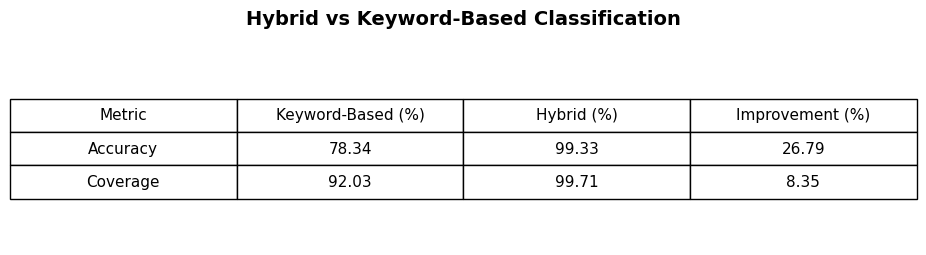

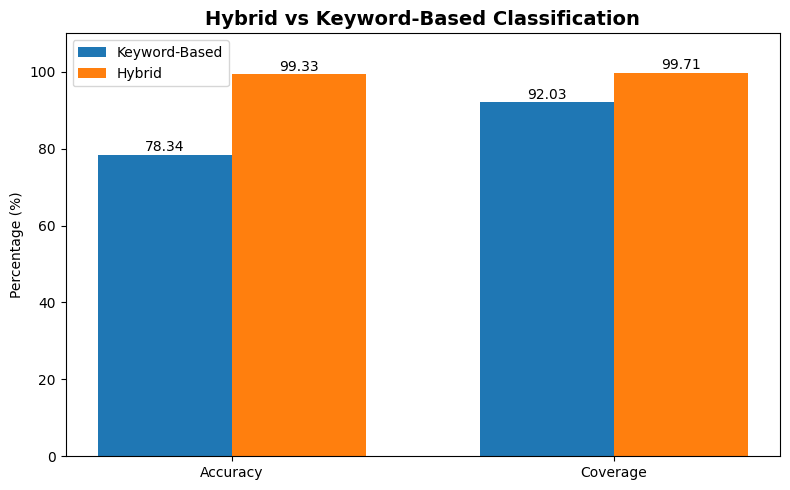

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Results
keyword_accuracy = 78.34
hybrid_accuracy = 99.33

keyword_coverage = 92.03
hybrid_coverage = 99.71

# Create dataframe
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Coverage"],
    "Keyword-Based (%)": [keyword_accuracy, keyword_coverage],
    "Hybrid (%)": [hybrid_accuracy, hybrid_coverage]
})

comparison["Improvement (%)"] = (
    (comparison["Hybrid (%)"] - comparison["Keyword-Based (%)"])
    / comparison["Keyword-Based (%)"]
) * 100

# ==================================================
# IMAGE 1 : TABLE
# ==================================================

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')

table = ax.table(
    cellText=comparison.round(2).values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2)

plt.title(
    "Hybrid vs Keyword-Based Classification",
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.savefig(
    "performance_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ==================================================
# IMAGE 2 : BAR CHART
# ==================================================

metrics = ["Accuracy", "Coverage"]

keyword_scores = [
    keyword_accuracy,
    keyword_coverage
]

hybrid_scores = [
    hybrid_accuracy,
    hybrid_coverage
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width/2 for i in x],
    keyword_scores,
    width,
    label="Keyword-Based"
)

plt.bar(
    [i + width/2 for i in x],
    hybrid_scores,
    width,
    label="Hybrid"
)

plt.xticks(x, metrics)
plt.ylabel("Percentage (%)")
plt.ylim(0, 110)

plt.title(
    "Hybrid vs Keyword-Based Classification",
    fontsize=14,
    fontweight='bold'
)

plt.legend()

# Values on bars
for i, v in enumerate(keyword_scores):
    plt.text(
        i - width/2,
        v + 1,
        f"{v:.2f}",
        ha='center'
    )

for i, v in enumerate(hybrid_scores):
    plt.text(
        i + width/2,
        v + 1,
        f"{v:.2f}",
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    "performance_bar_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()